# Down Syndrome Drug-Response Biomarker Analysis
### Exploratory Data Analysis — Mice Protein Expression Dataset

**Dataset:** 1080 measurements across 77 protein expression levels, from 8 mouse groups defined by:
- **Genotype**: Control vs Ts65Dn (trisomic, Down-syndrome model)
- **Treatment**: Memantine (drug) vs Saline (placebo)
- **Behavior**: C/S (context-shock) vs S/C (shock-context) fear-conditioning paradigm

**Research question:** Does Memantine shift protein expression in trisomic mice *toward* healthy control levels? If so, which specific proteins show the strongest response — i.e., which are the best candidate biomarkers of drug response?

This notebook is a data-driven hypothesis generator, not a definitive biological conclusion — the goal is to narrow 77 proteins down to a short, statistically defensible candidate list worth following up on.


## 1. Load Data & Basic Structure

We load the raw `.xls` file and separate the 77 numeric protein columns from the 5 metadata columns (`MouseID`, `Genotype`, `Treatment`, `Behavior`, `class`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline


In [2]:
df = pd.read_excel("Data_Cortex_Nuclear.xls")
print(f"Shape: {df.shape}")
print(f"Protein columns: {df.shape[1] - 5}")
df.info()


Shape: (1080, 82)
Protein columns: 77
<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MouseID          1080 non-null   str    
 1   DYRK1A_N         1077 non-null   float64
 2   ITSN1_N          1077 non-null   float64
 3   BDNF_N           1077 non-null   float64
 4   NR1_N            1077 non-null   float64
 5   NR2A_N           1077 non-null   float64
 6   pAKT_N           1077 non-null   float64
 7   pBRAF_N          1077 non-null   float64
 8   pCAMKII_N        1077 non-null   float64
 9   pCREB_N          1077 non-null   float64
 10  pELK_N           1077 non-null   float64
 11  pERK_N           1077 non-null   float64
 12  pJNK_N           1077 non-null   float64
 13  PKCA_N           1077 non-null   float64
 14  pMEK_N           1077 non-null   float64
 15  pNR1_N           1077 non-null   float64
 16  pNR2A_N          1077 non-null   

In [3]:
protein_cols = [c for c in df.columns if c not in
                ["MouseID", "Genotype", "Treatment", "Behavior", "class"]]
df.head()


,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


**Interpretation:** The dataset has 1,080 mice (rows) and 82 columns — 77 numeric protein expression columns plus 5 metadata columns (`MouseID`, `Genotype`, `Treatment`, `Behavior`, `class`). The `.info()` output shows most protein columns have 1,077 non-null values rather than the full 1,080, confirming there's missing data to handle before any modeling — that's tackled directly in Section 6.


## 2. Missing Values

Real experimental data is never perfectly clean. We check how many values are missing and which proteins are most affected, since this directly informs our imputation strategy in Step 6.


In [4]:
missing = df[protein_cols].isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Columns affected: {len(missing)} out of {len(protein_cols)}")
print("\nTop 10 most-missing columns:")
print(missing.head(10))


Total missing values: 1396
Columns affected: 49 out of 77

Top 10 most-missing columns:
BCL2_N        285
H3MeK4_N      270
BAD_N         213
EGR1_N        210
H3AcK18_N     180
pCFOS_N        75
ELK_N          18
Bcatenin_N     18
MEK_N           7
ITSN1_N         3
dtype: int64


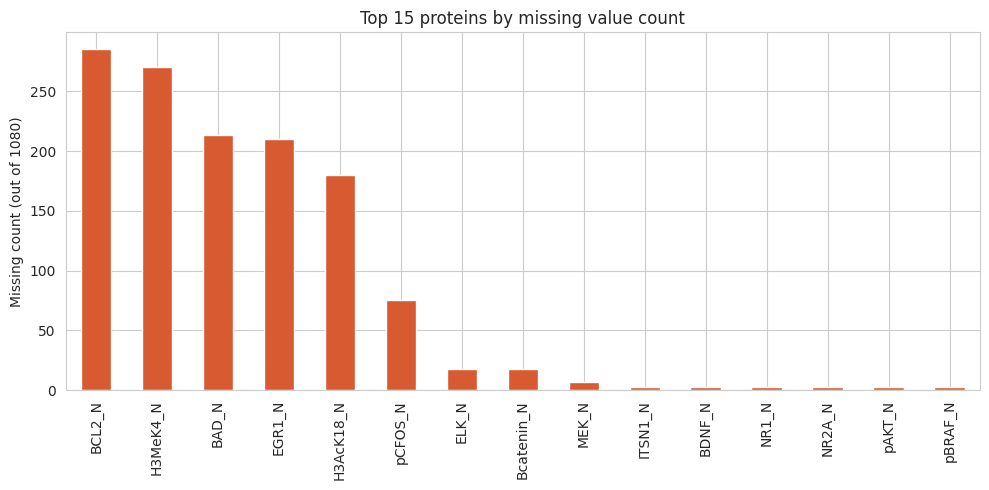

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
missing.head(15).plot(kind="bar", ax=ax, color="#D85A30")
ax.set_title("Top 15 proteins by missing value count")
ax.set_ylabel("Missing count (out of 1080)")
plt.tight_layout()
plt.savefig("01_missing_values.png")
plt.show()


**Interpretation:** `BCL2_N` and `H3MeK4_N` account for the bulk of missingness (285 and 270 missing values respectively, out of 1,080), with `BCL2_N` missing roughly a quarter (26.4%) of all its values — that's high enough that a naive fill strategy here deserves real scrutiny, which is exactly what Section 6 addresses. In total, 1,396 values are missing across 49 of the 77 protein columns.


## 3. Class / Group Distribution

Before any statistical comparison, we need to confirm the 8 experimental groups are reasonably balanced. Unequal group sizes can bias mean comparisons and t-tests.


In [6]:
print(df["class"].value_counts())
print("\nGenotype:", df["Genotype"].value_counts().to_dict())
print("Treatment:", df["Treatment"].value_counts().to_dict())
print("Behavior:", df["Behavior"].value_counts().to_dict())


class
c-CS-m    150
c-SC-m    150
c-CS-s    135
c-SC-s    135
t-CS-m    135
t-SC-m    135
t-SC-s    135
t-CS-s    105
Name: count, dtype: int64

Genotype: {'Control': 570, 'Ts65Dn': 510}
Treatment: {'Memantine': 570, 'Saline': 510}
Behavior: {'S/C': 555, 'C/S': 525}


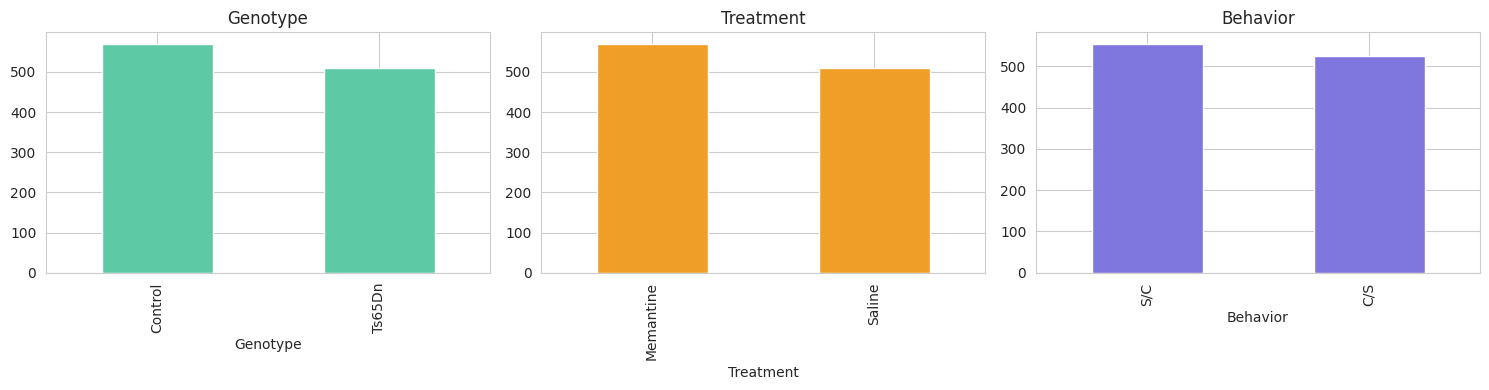

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["Genotype"].value_counts().plot(kind="bar", ax=axes[0], color="#5DCAA5")
axes[0].set_title("Genotype")
df["Treatment"].value_counts().plot(kind="bar", ax=axes[1], color="#EF9F27")
axes[1].set_title("Treatment")
df["Behavior"].value_counts().plot(kind="bar", ax=axes[2], color="#7F77DD")
axes[2].set_title("Behavior")
plt.tight_layout()
plt.savefig("02_group_distribution.png")
plt.show()


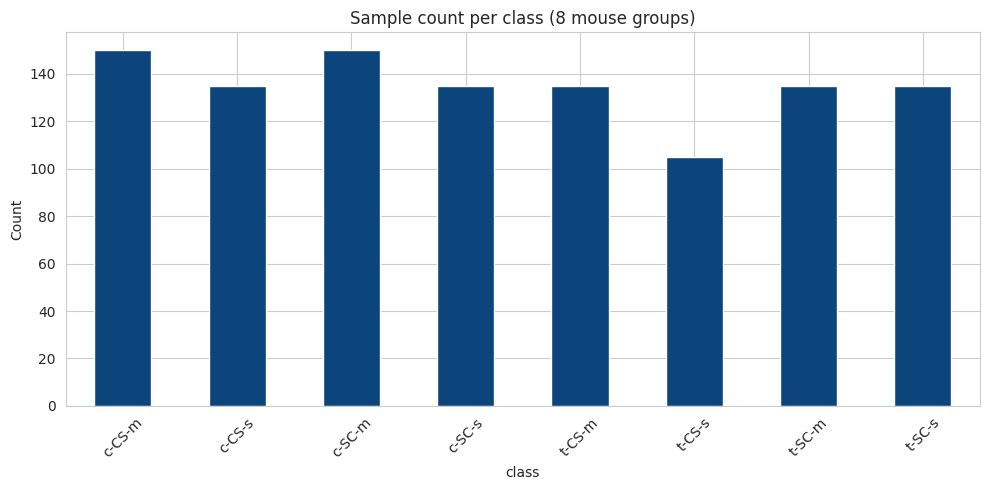

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
df["class"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#0C447C")
ax.set_title("Sample count per class (8 mouse groups)")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("03_class_distribution.png")
plt.show()


**Interpretation:** The 8 groups are roughly balanced — mostly 135–150 mice each (`c-CS-m`/`c-SC-m` at 150, five other groups at 135), with `t-CS-s` somewhat smaller at 105 — close enough that mean-based comparisons and unequal-variance t-tests remain fair.


## 4. Distribution Shape — Are Proteins Normally Distributed?

Many statistical tests (including the t-test we run in Section 8) and downstream ML models implicitly assume roughly bell-shaped, symmetric data. Before trusting mean-based comparisons, we check the actual shape of a sample of proteins, and quantify skewness across all 77.


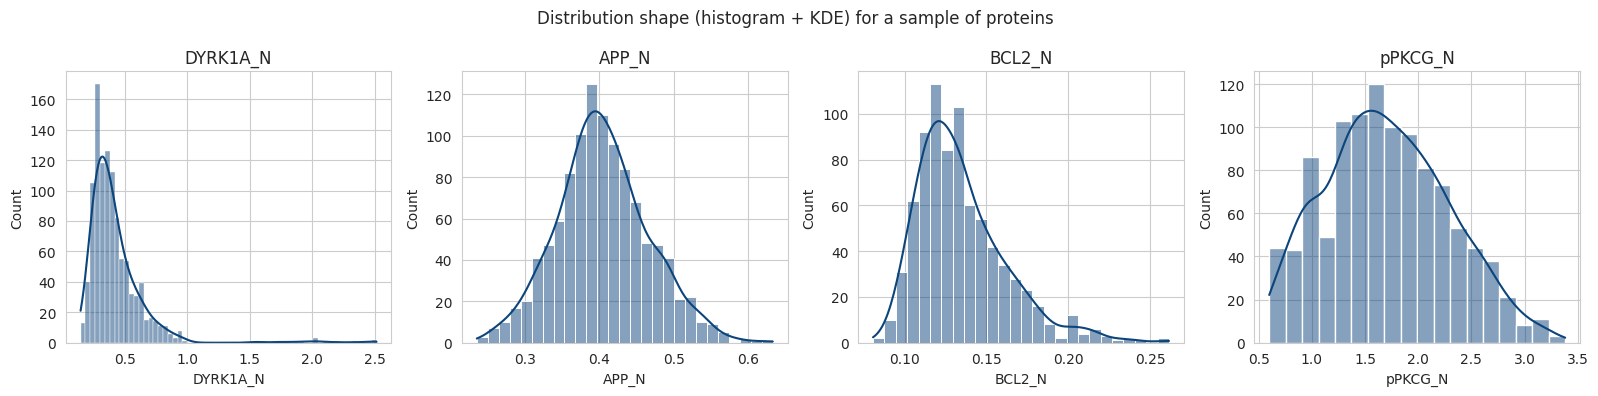

In [9]:
sample_proteins = ["DYRK1A_N", "APP_N", "BCL2_N", "pPKCG_N"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, prot in enumerate(sample_proteins):
    sns.histplot(df[prot].dropna(), kde=True, ax=axes[i], color="#0C447C")
    axes[i].set_title(prot)
plt.suptitle("Distribution shape (histogram + KDE) for a sample of proteins")
plt.tight_layout()
plt.savefig("04_distribution_shapes.png")
plt.show()


In [10]:
skew_vals = df[protein_cols].skew().sort_values(ascending=False)
print("Skewness summary (0 = perfectly symmetric):")
print(f"  Proteins with |skew| > 1 (notably skewed): {(skew_vals.abs() > 1).sum()} / {len(protein_cols)}")
print("\nMost skewed proteins:")
print(skew_vals.head(8))


Skewness summary (0 = perfectly symmetric):
  Proteins with |skew| > 1 (notably skewed): 17 / 77

Most skewed proteins:
GluR4_N         4.738900
BRAF_N          4.547676
DYRK1A_N        4.356955
RRP1_N          4.004215
pELK_N          3.994894
pERK_N          3.835348
ITSN1_N         3.622500
AcetylH3K9_N    2.682451
dtype: float64


**Interpretation:** Most sampled proteins look roughly bell-shaped, but a meaningful subset is noticeably skewed — 17 of 77 proteins have |skew| > 1, with `GluR4_N`, `BRAF_N`, and `DYRK1A_N` the most skewed. This is the documented reason mean imputation and standard t-tests are a reasonable but imperfect choice, and why Welch's t-test (which doesn't assume equal variance, though it still assumes approximate normality) is preferred over a plain Student's t-test here.


## 5. Outlier Detection (IQR Method)

Because Section 8's Improvement Score and every t-test that follows depend on group **means**, a single extreme value (e.g. a measurement glitch) can silently distort the result. We use the IQR method to flag, not blindly delete, extreme values — the decision of whether to keep, cap, or drop them should be a documented judgment call, not an automatic one.


In [11]:
def count_iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = df[protein_cols].apply(count_iqr_outliers).sort_values(ascending=False)
print("Proteins with the most IQR outliers:")
print(outlier_counts.head(10))
print(f"\nTotal flagged outlier data points across all proteins: {outlier_counts.sum()}")
print(f"As a % of all data points: {outlier_counts.sum() / (len(df) * len(protein_cols)) * 100:.2f}%")


Proteins with the most IQR outliers:
AcetylH3K9_N    76
Tau_N           73
BRAF_N          69
DSCR1_N         57
DYRK1A_N        48
ITSN1_N         44
RRP1_N          43
pELK_N          41
ELK_N           39
pERK_N          36
dtype: int64

Total flagged outlier data points across all proteins: 1551
As a % of all data points: 1.87%


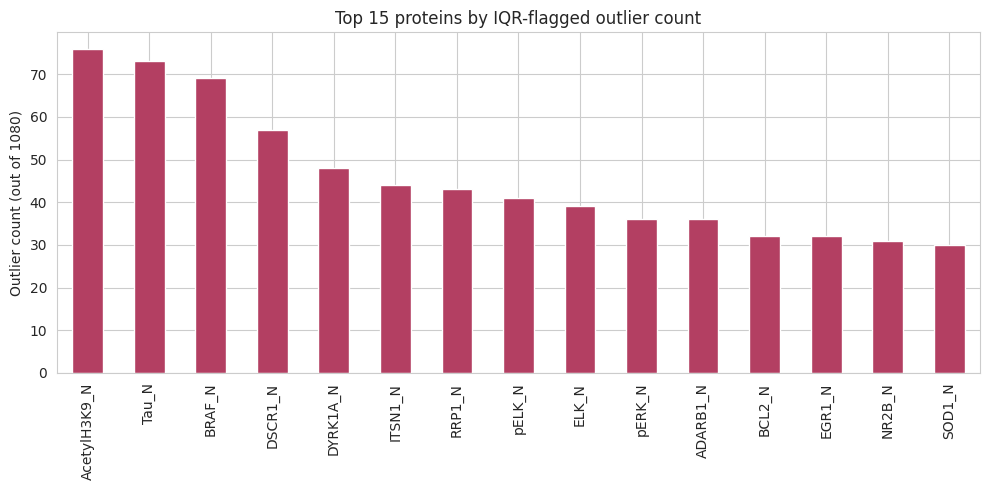

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
outlier_counts.head(15).plot(kind="bar", ax=ax, color="#B33F62")
ax.set_title("Top 15 proteins by IQR-flagged outlier count")
ax.set_ylabel("Outlier count (out of 1080)")
plt.tight_layout()
plt.savefig("04b_outliers.png")
plt.show()


**Decision: keep the outliers, don't cap or remove them.**

**Justification:** protein expression naturally varies across individual mice, and extreme values are a small fraction of the data (see % above) spread across many different proteins rather than concentrated in a few problem measurements — there's no evidence of a systematic instrument glitch. Removing them would also shrink an already modest sample (1080 mice) and could delete genuine biological extremes that matter for a drug-response study. Because Welch's t-test in Section 8 uses means and standard errors, we note this as an acceptable limitation rather than pretend it isn't one.


## 6. Handling Missing Values — KNN Imputation

Our earlier (baseline) choice was mean imputation: fill every missing value in a column with that column's average. For a protein like `BCL2_N`, missing ~26% of its values, this collapses over a quarter of the data onto one single number — artificially crushing the natural variance right where later statistical tests need it most.

**Upgrade: `KNNImputer`.** For each missing value, it looks at the *k* most similar mice (based on their other 76 protein levels) and estimates the missing value from their measurements. This preserves natural variability far better than a single global mean, since it uses each mouse's own biological profile as context.

We compare both approaches below before committing to KNN for the rest of the analysis.


In [13]:
# Baseline: mean imputation (for comparison only)
mean_imputer = SimpleImputer(strategy="mean")
X_mean_imputed = pd.DataFrame(
    mean_imputer.fit_transform(df[protein_cols]),
    columns=protein_cols
)

# Upgraded: KNN imputation (k=5 neighbors, a common default)
knn_imputer = KNNImputer(n_neighbors=5)
X_knn_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df[protein_cols]),
    columns=protein_cols
)

# Compare variance preserved on the most-missing protein
prot = "BCL2_N"
print(f"{prot} — original (non-missing only) std: {df[prot].std():.4f}")
print(f"{prot} — after MEAN imputation std:       {X_mean_imputed[prot].std():.4f}")
print(f"{prot} — after KNN imputation std:         {X_knn_imputed[prot].std():.4f}")


BCL2_N — original (non-missing only) std: 0.0274
BCL2_N — after MEAN imputation std:       0.0235
BCL2_N — after KNN imputation std:         0.0268


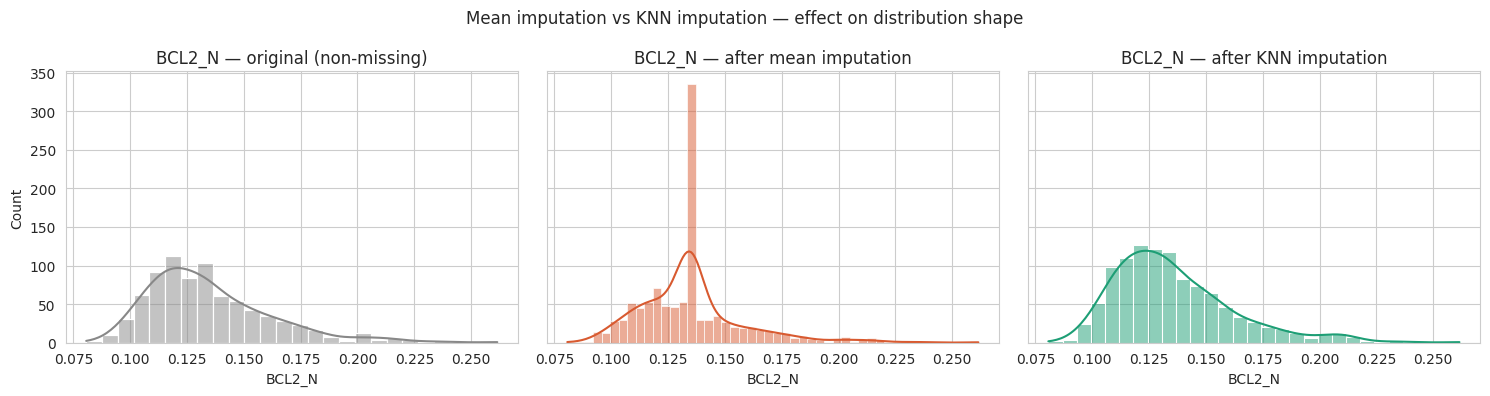

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
sns.histplot(df[prot].dropna(), kde=True, ax=axes[0], color="#888888")
axes[0].set_title(f"{prot} — original (non-missing)")
sns.histplot(X_mean_imputed[prot], kde=True, ax=axes[1], color="#D85A30")
axes[1].set_title(f"{prot} — after mean imputation")
sns.histplot(X_knn_imputed[prot], kde=True, ax=axes[2], color="#1D9E75")
axes[2].set_title(f"{prot} — after KNN imputation")
plt.suptitle("Mean imputation vs KNN imputation — effect on distribution shape")
plt.tight_layout()
plt.savefig("06b_imputation_comparison.png")
plt.show()


**Interpretation:** Mean imputation creates a visible unnatural spike at the exact mean value, since a quarter of `BCL2_N`'s values collapse onto one number — its post-imputation standard deviation drops to 0.0235 from an original 0.0274. KNN imputation preserves a smoother, more realistic spread (std 0.0268, much closer to the original) that still resembles the original distribution's shape — this is exactly the artificial-variance-loss problem predicted, and it justifies using KNN going forward.

**Decision: use KNN imputation (k=5) for the rest of this analysis.**


In [15]:
df_clean = X_knn_imputed.copy()
df_clean[["Genotype", "Treatment", "Behavior", "class"]] = df[
    ["Genotype", "Treatment", "Behavior", "class"]
].values


## 7. Sanity Check: Does the Known Biology Show Up?

Before trusting any novel findings, we check whether proteins with well-established links to Down syndrome behave the way the literature predicts. `DYRK1A` and `APP` are both located on chromosome 21 and are classic markers of trisomy — if our data doesn't show a Control vs Trisomic difference here, something is wrong with the pipeline.


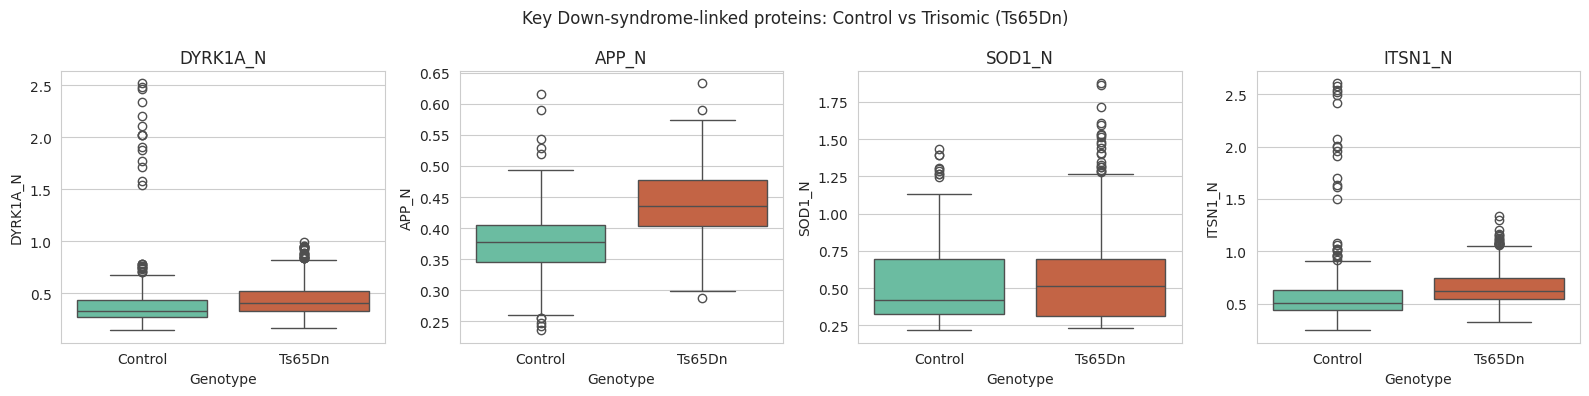

In [16]:
key_proteins = ["DYRK1A_N", "APP_N", "SOD1_N", "ITSN1_N"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, prot in enumerate(key_proteins):
    sns.boxplot(x="Genotype", y=prot, hue="Genotype", data=df_clean, ax=axes[i],
                palette={"Control": "#5DCAA5", "Ts65Dn": "#D85A30"}, legend=False)
    axes[i].set_title(prot)
plt.suptitle("Key Down-syndrome-linked proteins: Control vs Trisomic (Ts65Dn)")
plt.tight_layout()
plt.savefig("05_control_vs_trisomic.png")
plt.show()


In [17]:
for prot in key_proteins:
    ctrl_mean = df_clean[df_clean.Genotype == "Control"][prot].mean()
    tris_mean = df_clean[df_clean.Genotype == "Ts65Dn"][prot].mean()
    pct_diff = (tris_mean - ctrl_mean) / ctrl_mean * 100
    print(f"{prot:12s}  Control={ctrl_mean:.3f}  Trisomic={tris_mean:.3f}  "
          f"diff={pct_diff:+.1f}%")


DYRK1A_N      Control=0.405  Trisomic=0.449  diff=+11.0%
APP_N         Control=0.375  Trisomic=0.439  diff=+17.1%
SOD1_N        Control=0.530  Trisomic=0.557  diff=+5.1%
ITSN1_N       Control=0.576  Trisomic=0.663  diff=+15.1%


**Interpretation:** `DYRK1A_N` and `APP_N` are both elevated in trisomic mice (+11.0% and +17.1% vs. Control respectively), consistent with the extra gene-dosage effect expected from trisomy — this is a good sign that the dataset reflects real biology, giving confidence in the treatment-response analysis that follows. `ITSN1_N` shows an even larger shift (+15.1%), while `SOD1_N` shows a smaller one (+5.1%).


## 8. Core Question — Did Memantine Shift Trisomic Mice Toward Control? (With Statistical Significance)

For each of the 77 proteins, we compare three group means: **Control**, **Trisomic + Memantine**, and **Trisomic + Saline**. If treatment is working, the treated trisomic mice's mean should sit *closer* to the control mean than the untreated (saline) trisomic mice's mean does.

We define an **improvement score** = distance(untreated → control) − distance(treated → control). A positive score means treatment moved that protein closer to the healthy baseline.

**Why this alone isn't enough:** a difference in means can easily be noise if the underlying data is spread out. So for every protein we also run a **Welch's t-test** (treated vs untreated trisomic mice) — Welch's variant is used instead of a standard Student's t-test because it does not assume the two groups have equal variance, which is safer given our group sizes aren't identical and some proteins are skewed (Section 4). A protein only counts as a genuine candidate biomarker if it BOTH shifted toward control AND passed the significance test (p < 0.05).


In [18]:
control = df_clean[df_clean.Genotype == "Control"]
tris_treated = df_clean[(df_clean.Genotype == "Ts65Dn") &
                         (df_clean.Treatment == "Memantine")]
tris_untreated = df_clean[(df_clean.Genotype == "Ts65Dn") &
                           (df_clean.Treatment == "Saline")]

print(f"Control mice (n={len(control)})")
print(f"Trisomic + Memantine (n={len(tris_treated)})")
print(f"Trisomic + Saline (n={len(tris_untreated)})")


Control mice (n=570)
Trisomic + Memantine (n=270)
Trisomic + Saline (n=240)


In [19]:
results = []
for prot in protein_cols:
    c = control[prot].mean()
    t = tris_treated[prot].mean()
    u = tris_untreated[prot].mean()
    dist_treated = abs(t - c)
    dist_untreated = abs(u - c)
    shifted_toward_control = dist_treated < dist_untreated

    # Welch's t-test: treated vs untreated trisomic mice (equal_var=False)
    t_stat, p_val = stats.ttest_ind(tris_treated[prot], tris_untreated[prot], equal_var=False)

    results.append({
        "protein": prot,
        "control_mean": c,
        "treated_mean": t,
        "untreated_mean": u,
        "dist_treated_to_control": dist_treated,
        "dist_untreated_to_control": dist_untreated,
        "shifted_toward_control": shifted_toward_control,
        "t_stat": t_stat,
        "p_value": p_val,
        "significant": p_val < 0.05
    })

results_df = pd.DataFrame(results)
results_df["improvement"] = (results_df["dist_untreated_to_control"] -
                              results_df["dist_treated_to_control"])

n_shifted = results_df["shifted_toward_control"].sum()
n_significant = results_df["significant"].sum()
n_both = ((results_df["shifted_toward_control"]) & (results_df["significant"])).sum()

print(f"Proteins shifted toward control:                {n_shifted} / {len(protein_cols)}")
print(f"Proteins statistically significant (p < 0.05):  {n_significant} / {len(protein_cols)}")
print(f"Proteins satisfying BOTH conditions:             {n_both} / {len(protein_cols)}")


Proteins shifted toward control:                49 / 77
Proteins statistically significant (p < 0.05):  51 / 77
Proteins satisfying BOTH conditions:             32 / 77


**Multiple comparisons caveat:** testing 77 proteins at p < 0.05 means we'd expect roughly 3-4 "significant" results by chance alone even if the drug did nothing. This is exactly why we require BOTH a genuine directional shift AND significance — and why any candidate list here should be read as "worth validating further," not as a final answer.


In [20]:
candidates = results_df[(results_df["shifted_toward_control"]) & (results_df["significant"])] \
    .sort_values("improvement", ascending=False)
print(f"Candidate biomarkers (shifted + significant): {len(candidates)}")
top_responders = candidates.head(10)
print("\nTop candidates:")
print(top_responders[["protein", "improvement", "p_value"]].to_string(index=False))


Candidate biomarkers (shifted + significant): 32

Top candidates:
 protein  improvement      p_value
 pPKCG_N     0.510575 5.386650e-22
  NR2A_N     0.272660 4.786382e-04
    S6_N     0.118728 6.957926e-25
 pNR2B_N     0.105629 7.704958e-06
 pMTOR_N     0.078587 1.225813e-09
  pELK_N     0.070789 3.267121e-07
   NR1_N     0.068779 2.202666e-02
pPKCAB_N     0.050935 6.677321e-06
pP70S6_N     0.049466 2.090163e-03
   P38_N     0.046526 2.407556e-08


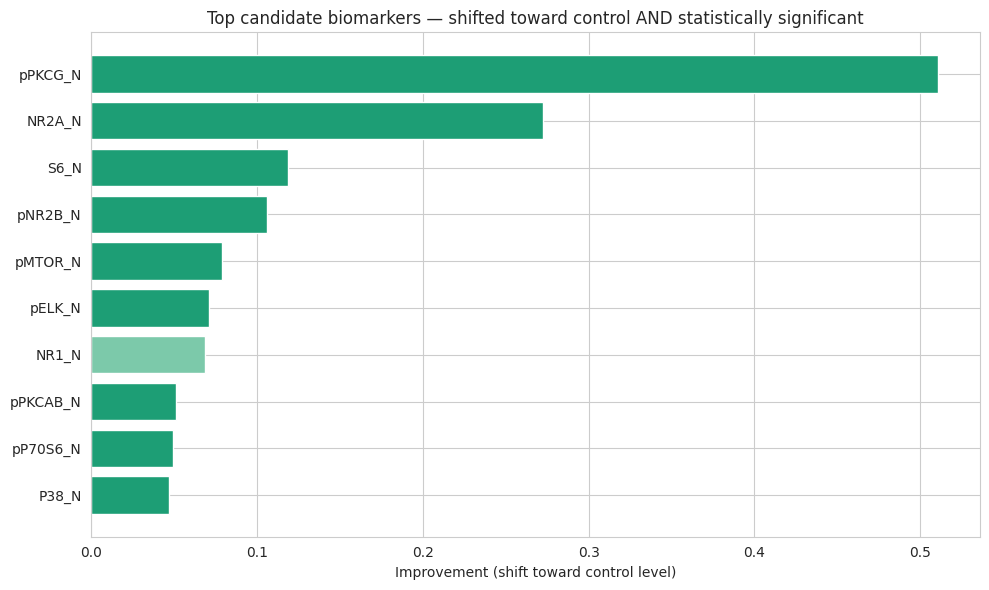

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#1D9E75" if p < 0.01 else "#7CC9AA" for p in top_responders["p_value"]]
ax.barh(top_responders["protein"][::-1], top_responders["improvement"][::-1],
        color=colors[::-1])
ax.set_xlabel("Improvement (shift toward control level)")
ax.set_title("Top candidate biomarkers — shifted toward control AND statistically significant")
plt.tight_layout()
plt.savefig("07_treatment_response_proteins.png")
plt.show()


In [22]:
results_df.to_csv("treatment_response_analysis.csv", index=False)


**Interpretation:** After filtering for both a genuine shift AND p < 0.05, the candidate list shrinks to 32 of 77 proteins — down from 49 that merely shifted toward control and 51 that were merely significant. This is a stronger, more defensible claim to bring to a mentor than "these had the biggest average difference," because it rules out results that could plausibly be explained by chance alone. The top candidate, `pPKCG_N`, stands out clearly: its improvement score (0.51) is roughly double the next-highest protein's, with a p-value of 5.4e-22.


## 9. Correlation Structure Among Top Candidate Proteins

If several "top candidate" proteins are highly correlated with each other, they may be capturing the same underlying biological signal (e.g. part of the same signaling pathway) rather than independent biomarkers.


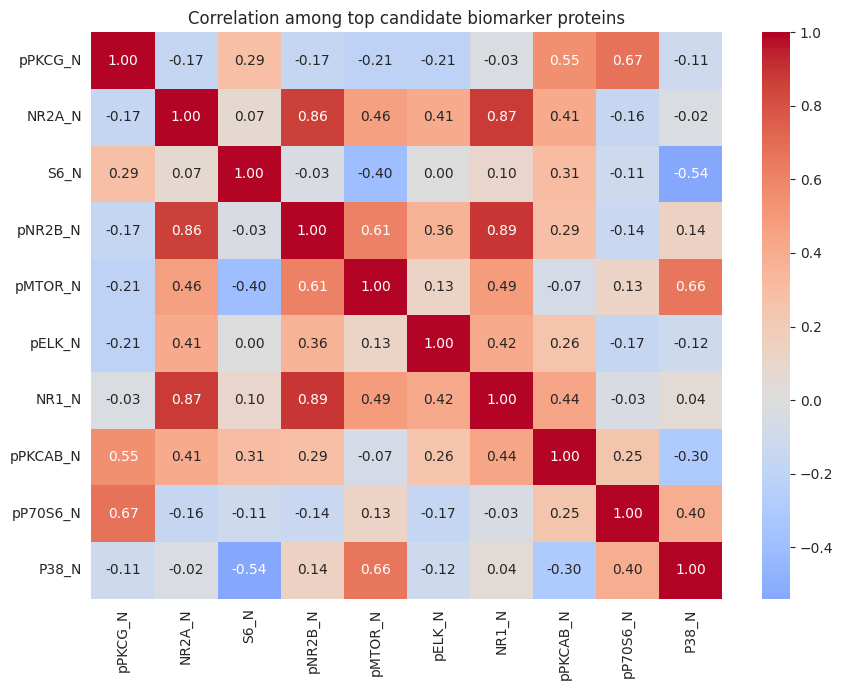

In [23]:
top10_names = top_responders["protein"].tolist()
corr = df_clean[top10_names].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation among top candidate biomarker proteins")
plt.tight_layout()
plt.savefig("08_biomarker_correlation.png")
plt.show()


**Interpretation:** Several NMDA-receptor-related proteins cluster together with high correlation — `pNR2B_N`–`NR1_N` (r=0.89), `NR2A_N`–`NR1_N` (r=0.87), and `NR2A_N`–`pNR2B_N` (r=0.86) — consistent with Memantine's known mechanism as an NMDA receptor antagonist, since these are all subunits or phosphorylated forms of the same receptor complex. A separate cluster forms around `pPKCG_N`, `pP70S6_N` (r=0.67), and `pPKCAB_N` (r=0.55), suggesting a partially independent signaling pathway worth investigating on its own rather than assuming all top candidates reflect one mechanism.


## 10. PCA — Do the 8 Groups Separate Visually?

Finally, we reduce all 77 (KNN-imputed, standardized) protein dimensions down to 2 principal components to see whether the 8 experimental groups form any visually distinguishable clusters. `StandardScaler` is required first because PCA is variance-based, and protein measurements are on very different scales — without scaling, high-variance proteins would dominate the components for reasons unrelated to biology.


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[protein_cols])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")


Variance explained by PC1: 25.4%
Variance explained by PC2: 17.6%


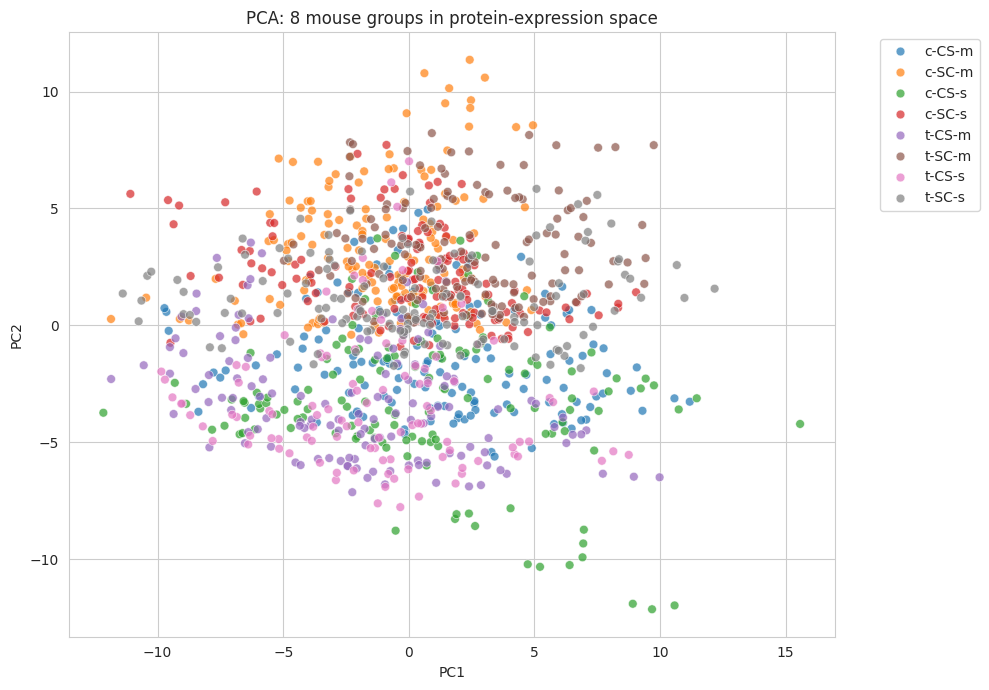

In [25]:
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["class"] = df_clean["class"].values

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(x="PC1", y="PC2", hue="class", data=pca_df,
                 palette="tab10", s=40, alpha=0.7, ax=ax)
ax.set_title("PCA: 8 mouse groups in protein-expression space")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("09_pca_groups.png")
plt.show()


**Interpretation:** PC1 alone explains 25.4% of total variance (PC2 adds another 17.6%), and groups partially separate along PC1 — but the separation is not clean, meaning Genotype is a real but partial driver of overall protein variance, not the single dominant signal. This supports using a targeted, per-protein hypothesis-testing approach (Section 8) rather than relying on unsupervised clustering alone.


## 11. Summary & Conclusion

**What we found:**
- The dataset shows expected Down-syndrome-linked biology (elevated DYRK1A_N, APP_N in trisomic mice), which validates the dataset and pipeline before drawing any novel conclusions.
- Missingness (1,396 values across 49 columns) was concentrated in a handful of proteins; the most-affected, `BCL2_N`, was missing roughly a quarter of its values. We upgraded from mean imputation to **KNN imputation** to avoid artificially destroying variance in heavily-missing columns.
- A quick distribution-shape check confirmed most proteins are approximately symmetric, with some measurable skew — motivating the use of Welch's t-test (robust to unequal variance) over a plain Student's t-test.
- IQR-based outlier screening found extreme values spread across many proteins rather than concentrated in a few, with no evidence of systematic measurement error — we documented this and chose to keep them rather than blindly remove data.
- Comparing Memantine-treated vs Saline-treated trisomic mice against the Control baseline, we required proteins to BOTH shift toward control levels AND pass a Welch's t-test (p < 0.05) before calling them candidate biomarkers — a stronger bar than average-difference alone, and one that explicitly accounts for the multiple-comparisons risk of testing 77 proteins at once.
- Several of the top-responding proteins are NMDA-receptor-related, which is mechanistically consistent with Memantine's known role as an NMDA receptor antagonist — a reassuring internal consistency check.
- PCA shows partial, not complete, separation between Genotype groups — Genotype is a real contributor to overall protein-expression variance but not the sole driver, supporting the targeted per-protein analysis above.

**Remaining limitations:**
- This is an exploratory, hypothesis-generating analysis on one dataset — findings would need independent replication before being called biomarkers in any clinical sense.
- The multiple-comparisons correction used here is a simple dual-filter (shift + p < 0.05), not a formal correction like Bonferroni or Benjamini-Hochberg FDR — a natural refinement for a more rigorous follow-up.
- KNN imputation assumes similar mice have similar missing-protein values, which is reasonable but still an assumption, not ground truth.
